In [17]:
from models import mSABR
def run_one(params):
    m = mSABR(**params)
    F, A = m.run()
    s = m.compute_stats(F)
    return {
        "mean_T": s["mean"][-1],
        "var_T":  s["variance"][-1],
        "skew_T": s["skewness"][-1],
        "kurt_T": s["kurtosis"][-1],
    }

In [18]:
import pandas as pd

baseline = dict(F0=100, A0=0.4, rho=-0.8, T=1.0, n_steps=252, n_paths=20000, beta=0.5, nu=0.4, lambda_=1.0, theta=0.2, seed=42)
sweep = {
    "lambda_": [0, 0.1, 1.0, 10],
    "nu": [0.1, 0.5, 1.0, 2.0],
    "beta": [0.0, 0.5, 1.0],
    "rho": [-0.8, 0.0, 0.8]
}
results = {}
for param_name, values in sweep.items():
    print(f"Running sweep for {param_name}...")
    rows = []
    for v in values:
        params = {**baseline, param_name: v}
        stats = run_one(params)
        rows.append({param_name:v, **stats})
    results[param_name] = pd.DataFrame(rows)

for name, df in results.items():
    print(f"\nResults for {name} sweep:")
    print(df)


Running sweep for lambda_...


/Users/anmol/Capstone-mSABR/stats.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return sc.stats.skew(paths, axis=0)
/Users/anmol/Capstone-mSABR/stats.py:16: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return sc.stats.kurtosis(paths, axis=0)


Running sweep for nu...
Running sweep for beta...
Running sweep for rho...

Results for lambda_ sweep:
   lambda_     mean_T      var_T    skew_T    kurt_T
0      0.0  99.974363  17.374503 -0.987901  2.088478
1      0.1  99.975857  16.495152 -0.960792  1.977875
2      1.0  99.985460  11.404546 -0.738140  1.183985
3     10.0  99.995150   5.064715 -0.138481  0.061797

Results for nu sweep:
    nu     mean_T      var_T    skew_T     kurt_T
0  0.1  99.992722  10.872526 -0.128734   0.055135
1  0.5  99.982764  11.747175 -0.975986   2.084065
2  1.0  99.967704  15.224893 -2.808066  18.452380
3  2.0  99.954473  35.445825 -7.202723  96.250099

Results for beta sweep:
   beta     mean_T        var_T    skew_T    kurt_T
0   0.0  99.998511     0.115114 -0.806012  1.419338
1   0.5  99.985460    11.404546 -0.738140  1.183985
2   1.0  99.915520  1030.804374  0.285139  0.064364

Results for rho sweep:
   rho     mean_T      var_T    skew_T    kurt_T
0 -0.8  99.985460  11.404546 -0.738140  1.183985
1  0

Note: When vol_of_vol coefficient is high, the path can go negative and that needs to be an absorbing state in the simulation

## Parameter Sweep Analysis

### λ (mean reversion speed)

As λ increases, the speed of mean reversion increases, so $A_t$ stays fixed near $\theta$ rather than wandering freely.

- **Variance decreases**: with $A$ fixed near $\theta$, the vol level is bounded which means smaller swings in $F$.
- **Kurtosis decreases**: the effect of vol-of-vol that produces fat tails (rare paths where $A$ explodes) is removed by strong mean reversion.
- **Mean estimate becomes more stable** at $F_0 = 100$. The true mean is 100 (since $F$ is a martingale), lower variance means the Monte Carlo estimator has smaller standard error.
- **Skew shrinks toward 0**: $\beta < 1$ produces negative skew, but its magnitude scales with the size of $F$'s moves, which scale with $A$. Since high λ keeps $A$ small and frozen, all skew channels weaken, so skew is roughly 0.

### ν (vol of vol)

As ν increases, the diffusion coefficient of $A$ grows, so $A$ wanders more aggressively.

- **Variance increases**: large values of $A$ become more likely so bigger swings in $F$.
- **Mean estimate becomes noisier**: higher variance inflates the standard error of the MC estimate.
- **Kurtosis increases**: $A$ follows geometric Brownian motion, so $A_T$ is log-normal with a heavy right tail. Paths with large $A$ produce extreme $F_T$ values which give fat tails in $F$.

### β (CEV exponent)

As β goes from 0 to 1, local vol $\sigma(F) = F^\beta$ changes from constant (normal) to proportional to $F$ (lognormal).

- **Variance increases dramatically**: at $F_0 = 100$, $A_0 = 0.4$:
  - $\beta = 0$: $A \cdot 1 = 0.4$ per unit $\sqrt{dt}$
  - $\beta = 0.5$: $A \cdot \sqrt{F} = 0.4 \cdot 10 = 4$
  - $\beta = 1$: $A \cdot F = 0.4 \cdot 100 = 40$
  
  Since variance scales like $vol^2$ the ratio is roughly $1 : 100 : 10000$ — matching the observed jump from 0.12 -> 11.5 -> 1152.
- **Mean estimate becomes noisier** higher variance inflates the standard error of the MC estimate.
- **Skew flips from negative to positive**: at $\beta = 0$, $F$ is normal-like (symmetric) and the only skew source is $\rho < 0$ which is slightly negative. At $\beta = 1$, $F$ becomes lognormal-like, which has strong positive skew.
- **Kurtosis increases**: lognormal tails are heavier than normal tails.

### ρ (correlation)

ρ controls the asymmetric coupling between moves in $F$ and moves in vol $A$.

- **Skew flips with ρ**:
  - $\rho < 0$: $F$ down <-> $A$ up -> vol rises during downturns -> fatter left tail -> **negative skew**.
  - $\rho = 0$: skew comes only from $\beta$ and $A$'s log-normality.
  - $\rho > 0$: $F$ up <-> $A$ up -> vol rises during rallies -> fatter right tail -> **positive skew**.
- **Mean, variance, and kurtosis remain mostly unchanged**: ρ mainly redistributes mass between left and right tails rather than changing how heavy the tails are overall.



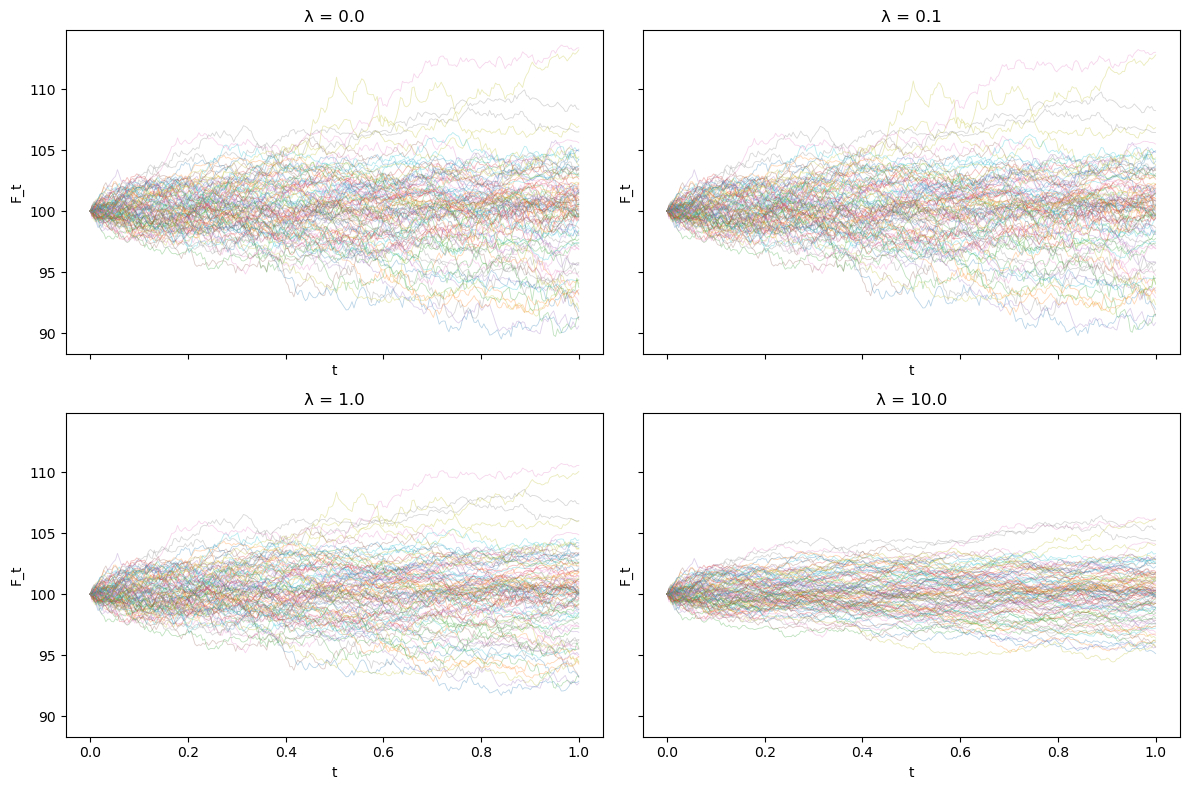

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_steps = 252
T = 1.0
n_show = 100
t_grid = np.linspace(0, T, n_steps + 1)

F_by_lambda = {}
for l in [0.0, 0.1, 1.0, 10.0]:
    params = {**baseline, "lambda_": l}
    m = mSABR(**params)
    F, _ = m.run()
    F_by_lambda[l] = F

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (l, F) in zip(axes.flat, F_by_lambda.items()):
    idx = np.random.default_rng(0).choice(F.shape[0], n_show, replace=False)
    ax.plot(t_grid, F[idx].T, alpha=0.3, linewidth=0.6)
    ax.set_title(f"λ = {l}")
    ax.set_xlabel("t")
    ax.set_ylabel("F_t")
plt.tight_layout()
plt.show()

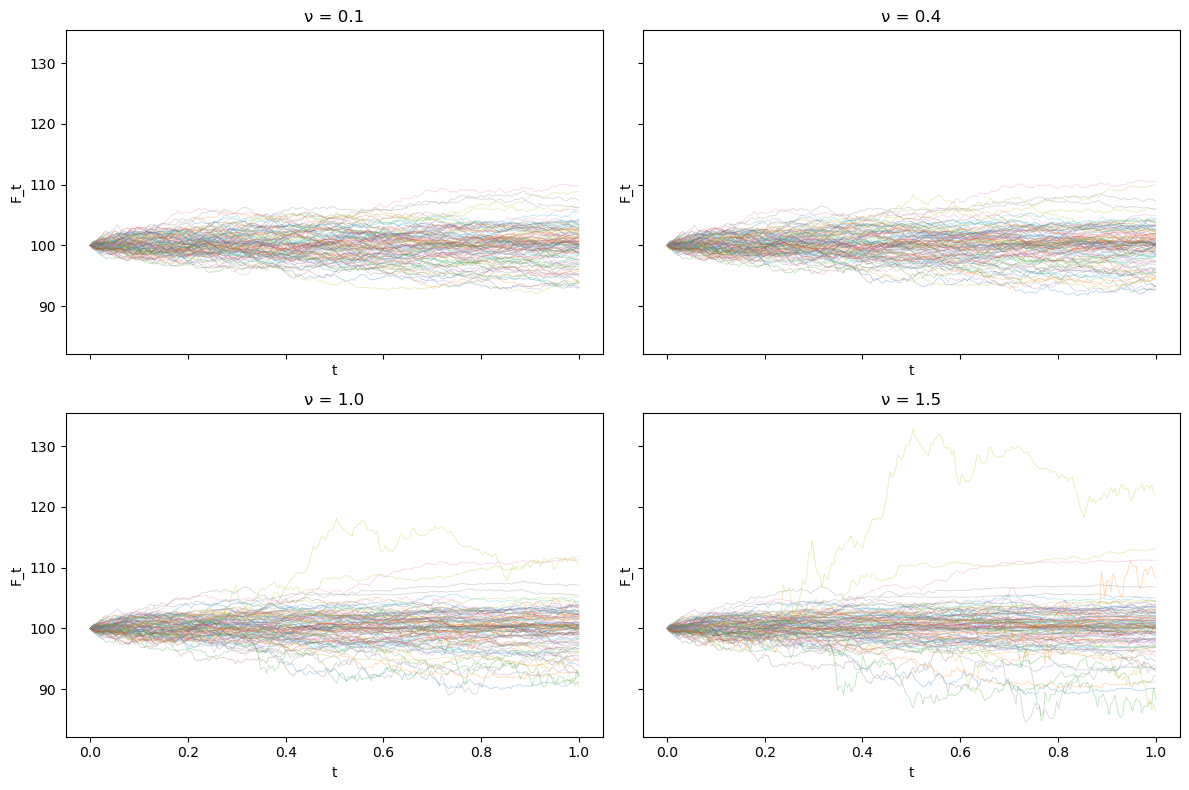

In [9]:
import matplotlib.pyplot as plt
import numpy as np

n_show = 100
t_grid = np.linspace(0, T, n_steps + 1)
nus = [0.1, 0.4, 1.0, 1.5]

F_by_nu = {}
for v in nus:
    params = {**baseline, "nu": v}
    m = mSABR(**params)
    F, _ = m.run()
    F_by_nu[v] = F

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (v, F) in zip(axes.flat, F_by_nu.items()):
    idx = np.random.default_rng(0).choice(F.shape[0], n_show, replace=False)
    ax.plot(t_grid, F[idx].T, alpha=0.3, linewidth=0.6)
    ax.set_title(f"ν = {v}")
    ax.set_xlabel("t")
    ax.set_ylabel("F_t")
plt.tight_layout()
plt.show()

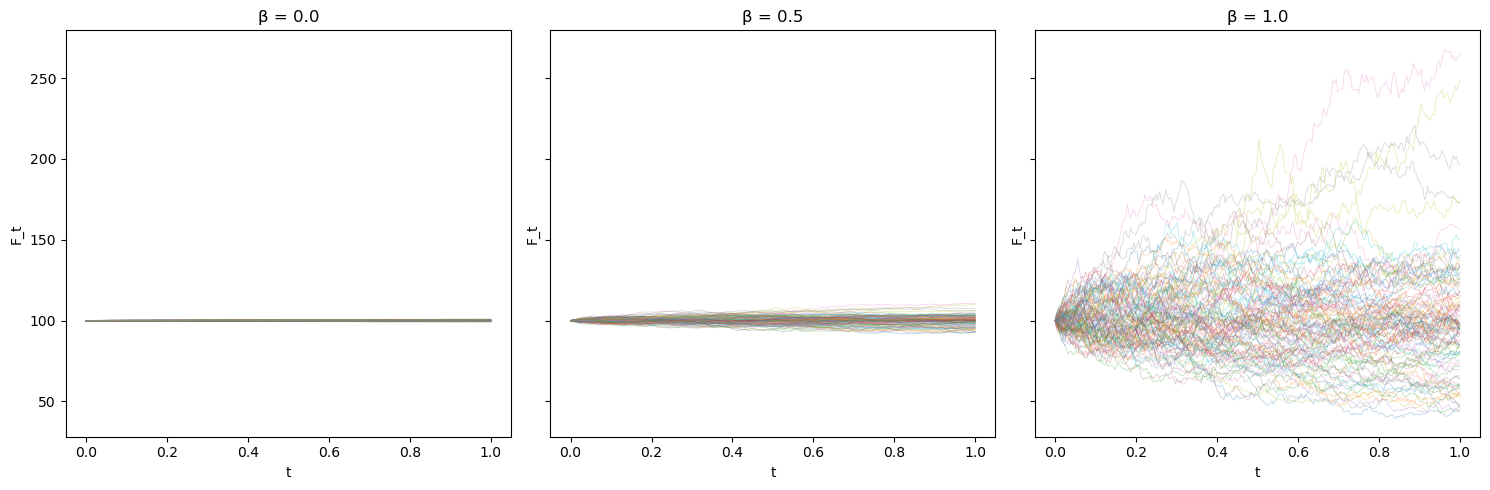

In [11]:
import matplotlib.pyplot as plt
import numpy as np

n_show = 100
t_grid = np.linspace(0, T, n_steps + 1)
betas = [0.0, 0.5, 1.0]

F_by_beta = {}
for b in betas:
    params = {**baseline, "beta": b}
    m = mSABR(**params)
    F, _ = m.run()
    F_by_beta[b] = F

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, (b, F) in zip(axes.flat, F_by_beta.items()):
    idx = np.random.default_rng(0).choice(F.shape[0], n_show, replace=False)
    ax.plot(t_grid, F[idx].T, alpha=0.3, linewidth=0.6)
    ax.set_title(f"β = {b}")
    ax.set_xlabel("t")
    ax.set_ylabel("F_t")
plt.tight_layout()
plt.show()

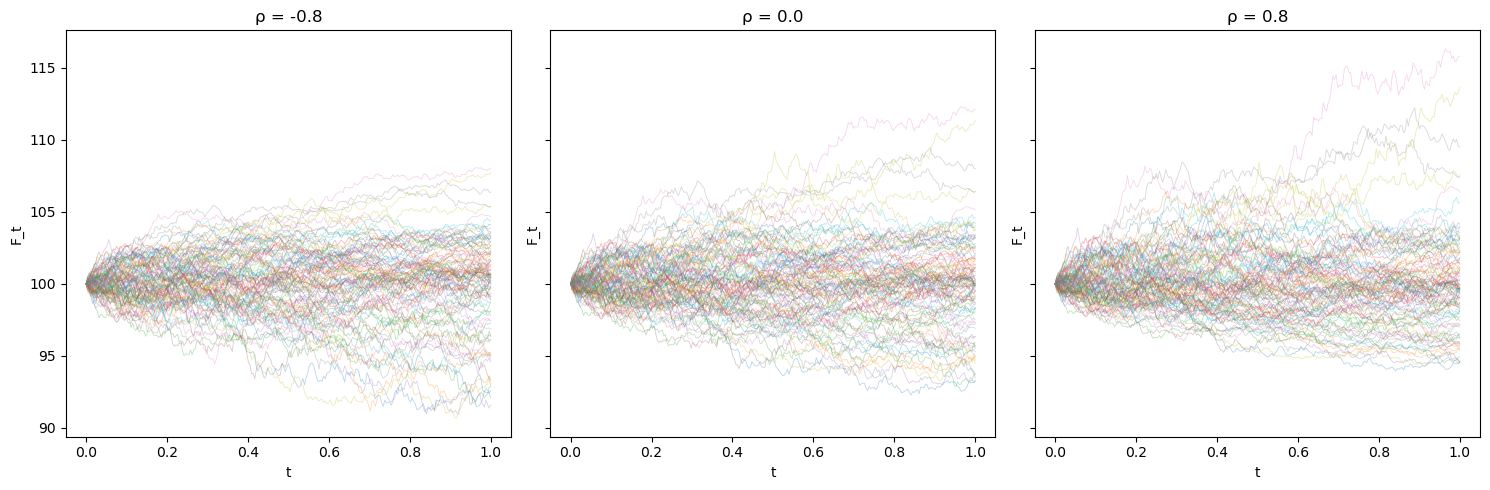

In [16]:
import matplotlib.pyplot as plt
import numpy as np

n_show = 100
t_grid = np.linspace(0, T, n_steps + 1)
rhos = [-0.8, 0.0, 0.8]

F_by_rho = {}
for r in rhos:
    params = {**baseline, "rho": r}
    m = mSABR(**params)
    F, _ = m.run()
    F_by_rho[r] = F

fig, axes = plt.subplots(1,3, figsize=(15, 5), sharex=True, sharey=True)
for ax, (r, F) in zip(axes.flat, F_by_rho.items()):
    idx = np.random.default_rng(0).choice(F.shape[0], n_show, replace=False)
    ax.plot(t_grid, F[idx].T, alpha=0.3, linewidth=0.6)
    ax.set_title(f"ρ = {r}")
    ax.set_xlabel("t")
    ax.set_ylabel("F_t")
plt.tight_layout()
plt.show()